# 青年城市生存力指数（YCSI）制图入口

不依赖 Jupyter 也可以制图：直接在项目根目录运行 `python ycsi_visualization.py`。

本 notebook 只作为可选入口，实际制图逻辑在 `ycsi_visualization.py`。

## 根据 task.md 需要完成的图

1. YCSI 排名柱状图
2. 全国城市生存力指数点状热力图
3. 工资 vs 租金收入比气泡图
4. 机会-居住压力四象限图
5. 典型城市五维雷达图
6. 生活便利 POI 构成图
7. 核心指标相关性热力图
8. K-Means 城市聚类图

可选扩展：通勤-租房地图和文本情绪词云，需要额外的区县租金/经纬度数据和城市评论文本。

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

import matplotlib

matplotlib.use("Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")



In [2]:
# 中文字体设置（根据系统可用字体调整）
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

In [3]:
# 目录常量
PROJECT_ROOT = Path.cwd()  # 或 Path(__file__).resolve().parent 在 notebook 中不可用
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
def read_csv_fallback(path: Path) -> pd.DataFrame:
    """尝试多种编码读取CSV"""
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "gb18030", "gbk"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error

def minmax(series: pd.Series) -> pd.Series:
    """最小-最大归一化，处理缺失值和全等数据"""
    values = pd.to_numeric(series, errors="coerce").astype(float)
    values = values.replace([np.inf, -np.inf], np.nan)
    values = values.fillna(values.median())
    span = values.max() - values.min()
    if pd.isna(span) or span == 0:
        return pd.Series(np.full(len(values), 0.5), index=series.index)
    return (values - values.min()) / span

def save_figure(filename: str) -> Path:
    """保存图片并关闭当前 figure"""
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()
    return path

def write_chart_plan() -> Path:
    """生成图表清单 Markdown 文件"""
    lines = [
        "# YCSI 可视化图表清单",
        "",
        "| 图表 | 对应研究问题 | 主要字段 | 输出文件 |",
        "|---|---|---|---|",
    ]
    for item in CHART_PLAN:   # CHART_PLAN 将在 Cell 3 定义
        lines.append(
            f"| {item['chart']} | {item['question']} | {item['fields']} | {item['output']} |"
        )
    lines.extend([
        "",
        "可选扩展：通勤-租房地图需要 `rent_data.csv` 中的区县/房源级租金、经纬度和就业中心数据；文本词云需要 `city_text.csv` 的 `city,text` 评论数据。",
        "",
    ])
    path = OUTPUT_DIR / "chart_plan.md"
    path.write_text("\n".join(lines), encoding="utf-8")
    return path

In [5]:
CITY_COORDS = {
    "北京": (116.4074, 39.9042), "上海": (121.4737, 31.2304),
    "广州": (113.2644, 23.1291), "深圳": (114.0579, 22.5431),
    "杭州": (120.1551, 30.2741), "南京": (118.7969, 32.0603),
    "苏州": (120.5853, 31.2989), "成都": (104.0665, 30.5728),
    "重庆": (106.5516, 29.5630), "武汉": (114.3054, 30.5931),
    "西安": (108.9398, 34.3416), "长沙": (112.9388, 28.2282),
    "郑州": (113.6254, 34.7466), "天津": (117.2000, 39.1333),
    "青岛": (120.3826, 36.0671),
}
COORDS_BY_ORDER = list(CITY_COORDS.values())  # 保持原顺序

POI_COLS = ["subway", "hospital", "park", "mall", "restaurant", "library", "gym"]
YCSI_FEATURES = [
    "opportunity_score", "rent_pressure", "life_score",
    "growth_score", "commute_score"
]
WEIGHTS = {
    "opportunity": 0.30, "life": 0.20, "growth": 0.20,
    "rent": 0.20, "commute": 0.10,
}

CHART_PLAN = [
    {"chart": "全国城市生存力指数点状热力图", "question": "15 个目标城市的综合友好度与空间分布",
     "fields": "city, lng, lat, YCSI, population", "output": "02_ycsi_city_heat_points.png"},
    {"chart": "YCSI 排名柱状图", "question": "哪些城市更适合作为毕业后的第一座城市",
     "fields": "YCSI, opportunity, life, growth, rent pressure, commute pressure",
     "output": "01_ycsi_ranking.png"},
    {"chart": "工资 vs 租金收入比气泡图", "question": "就业机会与租房压力是否匹配",
     "fields": "avg_salary, avg_rent, rent_income_ratio, job_count",
     "output": "03_salary_rent_bubble.png"},
    {"chart": "机会-居住压力四象限图", "question": "城市属于高机会高压力、低压稳健等哪类",
     "fields": "opportunity_score, rent_pressure, YCSI", "output": "04_opportunity_pressure_quadrant.png"},
    {"chart": "城市指标雷达图", "question": "典型城市在机会、居住、通勤、生活、成长上的差异",
     "fields": "five YCSI dimensions", "output": "05_city_radar.png"},
    {"chart": "生活便利 POI 构成图", "question": "城市日常生活便利度差异",
     "fields": "subway, hospital, park, mall, restaurant, library, gym",
     "output": "06_poi_convenience_stack.png"},
    {"chart": "指标相关性热力图", "question": "薪资、租金、生活便利、就业机会之间的关系",
     "fields": "salary, rent, job count, YCSI dimensions", "output": "07_metric_correlation_heatmap.png"},
    {"chart": "K-Means 城市聚类图", "question": "推荐不同类型青年适合的城市类别",
     "fields": "five YCSI dimensions", "output": "08_city_clusters.png"},
]

In [6]:
def load_base_data() -> pd.DataFrame:
    city_basic = read_csv_fallback(DATA_DIR / "city_basic.csv")
    poi = read_csv_fallback(DATA_DIR / "poi_data.csv")
    
    industry_path = PROJECT_ROOT / "city_basic_15_with_industry.csv"
    if industry_path.exists():
        industry = read_csv_fallback(industry_path)[[
            "city", "primary_industry_pct", "secondary_industry_pct", "tertiary_industry_pct"
        ]]
        city_basic = city_basic.merge(industry, on="city", how="left")
    else:
        for col in ["primary_industry_pct", "secondary_industry_pct", "tertiary_industry_pct"]:
            city_basic[col] = np.nan
    
    # 统一列名格式
    for df in (city_basic, poi):
        df.columns = [str(c).strip() for c in df.columns]
    
    metrics = city_basic.merge(poi, on="city", how="left")
    numeric_cols = [
        "gdp", "population", "disposable_income", "university_count", "metro_lines",
        "primary_industry_pct", "secondary_industry_pct", "tertiary_industry_pct", *POI_COLS
    ]
    for col in numeric_cols:
        if col in metrics.columns:
            metrics[col] = pd.to_numeric(metrics[col], errors="coerce")
            metrics[col] = metrics[col].fillna(metrics[col].median())
    
    # 添加经纬度
    coords = metrics["city"].map(CITY_COORDS)
    metrics["lng"] = coords.map(lambda x: x[0] if isinstance(x, tuple) else np.nan)
    metrics["lat"] = coords.map(lambda x: x[1] if isinstance(x, tuple) else np.nan)
    
    if metrics["lng"].isna().any() and len(metrics) == len(COORDS_BY_ORDER):
        ordered = pd.DataFrame(COORDS_BY_ORDER, columns=["lng_fallback", "lat_fallback"])
        metrics["lng"] = metrics["lng"].fillna(ordered["lng_fallback"])
        metrics["lat"] = metrics["lat"].fillna(ordered["lat_fallback"])
    
    return metrics

# 执行加载
base_metrics = load_base_data()
base_metrics.head()

,city,gdp,population,disposable_income,university_count,metro_lines,primary_industry_pct,secondary_industry_pct,tertiary_industry_pct,subway,hospital,park,mall,restaurant,library,gym,lng,lat
0,北京,43760,2185,81752,92,27,0.3,15.9,83.9,460,3639,3655,254,5591,598,3229,116.4074,39.9042
1,上海,47219,2476,84834,64,20,0.2,25.7,74.1,537,1969,2734,255,6254,582,4469,121.4737,31.2304
2,广州,30355,1873,78367,38,16,1.1,27.4,71.5,350,1892,2618,371,5006,497,2782,113.2644,23.1291
3,深圳,34606,1766,76910,15,16,0.1,38.3,61.6,455,424,2084,286,4043,790,3195,114.0579,22.5431
4,杭州,20059,1252,74832,46,12,1.8,30.0,68.2,329,2000,1633,200,4736,335,2818,120.1551,30.2741


In [7]:
def add_job_and_rent_metrics(metrics: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    metrics = metrics.copy()
    source_notes = []
    rng = np.random.default_rng(42)
    
    # 招聘数据
    job_path = DATA_DIR / "job_data.csv"
    if job_path.exists():
        job_df = read_csv_fallback(job_path)
        job_df.columns = [str(c).strip().lower() for c in job_df.columns]
        if {"city", "salary_min", "salary_max"}.issubset(job_df.columns):
            job_df["salary_min"] = pd.to_numeric(job_df["salary_min"], errors="coerce")
            job_df["salary_max"] = pd.to_numeric(job_df["salary_max"], errors="coerce")
            job_df["avg_salary"] = job_df[["salary_min", "salary_max"]].mean(axis=1)
            title_col = "job_title" if "job_title" in job_df.columns else "city"
            job_city = job_df.groupby("city", as_index=False).agg(
                avg_salary=("avg_salary", "mean"),
                job_count=(title_col, "count")
            )
            metrics = metrics.merge(job_city, on="city", how="left")
            source_notes.append("招聘数据：使用 data/job_data.csv。")
        else:
            source_notes.append("招聘数据：job_data.csv 字段不完整，改用演示估算。")
    
    if "avg_salary" not in metrics.columns or metrics["avg_salary"].isna().all():
        gdp_n = minmax(metrics["gdp"])
        income_n = minmax(metrics["disposable_income"])
        tertiary_n = minmax(metrics["tertiary_industry_pct"])
        university_n = minmax(metrics["university_count"])
        metrics["avg_salary"] = (
            metrics["disposable_income"] / 12 *
            (1.02 + 0.22 * gdp_n + 0.12 * tertiary_n + rng.normal(0, 0.025, len(metrics)))
        ).round(0)
        metrics["job_count"] = (
            850 + 5200 * (0.42 * gdp_n + 0.25 * income_n + 0.20 * university_n + 0.13 * tertiary_n)
            + rng.normal(0, 120, len(metrics))
        ).round(0).clip(lower=300).astype(int)
        source_notes.append("招聘数据：未发现可用 job_data.csv，使用宏观指标生成演示薪资/岗位数。")
    else:
        metrics["avg_salary"] = metrics["avg_salary"].fillna(metrics["avg_salary"].median())
        metrics["job_count"] = metrics["job_count"].fillna(metrics["job_count"].median()).astype(int)
    
    # 租房数据
    rent_path = DATA_DIR / "rent_data.csv"
    if rent_path.exists():
        rent_df = read_csv_fallback(rent_path)
        rent_df.columns = [str(c).strip().lower() for c in rent_df.columns]
        if {"city", "rent"}.issubset(rent_df.columns):
            rent_df["rent"] = pd.to_numeric(rent_df["rent"], errors="coerce")
            rent_city = rent_df.groupby("city", as_index=False).agg(avg_rent=("rent", "mean"))
            metrics = metrics.merge(rent_city, on="city", how="left")
            source_notes.append("租房数据：使用 data/rent_data.csv。")
        else:
            source_notes.append("租房数据：rent_data.csv 字段不完整，改用演示估算。")
    
    if "avg_rent" not in metrics.columns or metrics["avg_rent"].isna().all():
        gdp_n = minmax(metrics["gdp"])
        income_n = minmax(metrics["disposable_income"])
        metro_n = minmax(metrics["metro_lines"])
        pop_n = minmax(metrics["population"])
        rent_ratio = (
            0.22 + 0.22 * income_n + 0.10 * gdp_n + 0.05 * pop_n - 0.06 * metro_n
            + rng.normal(0, 0.018, len(metrics))
        ).clip(0.18, 0.62)
        metrics["avg_rent"] = (metrics["avg_salary"] * rent_ratio).round(0)
        source_notes.append("租房数据：未发现可用 rent_data.csv，使用宏观指标生成演示租金。")
    else:
        metrics["avg_rent"] = metrics["avg_rent"].fillna(metrics["avg_rent"].median())
    
    metrics["rent_income_ratio"] = metrics["avg_rent"] / metrics["avg_salary"]
    return metrics, source_notes

# 执行
metrics_with_job_rent, data_notes = add_job_and_rent_metrics(base_metrics)
metrics_with_job_rent[["city", "avg_salary", "avg_rent", "rent_income_ratio", "job_count"]].head()

,city,avg_salary,avg_rent,rent_income_ratio,job_count
0,北京,9170.0,4769.0,0.520065,5637
1,上海,9177.0,4834.0,0.526752,5514
2,广州,8020.0,3536.0,0.440898,3703
3,深圳,7839.0,3430.0,0.437556,3627
4,杭州,6760.0,2778.0,0.410947,3104


In [8]:
def calculate_ycsi(metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    metrics = metrics.copy()
    
    # 机会指数
    metrics["opportunity_score"] = (
        0.45 * minmax(metrics["avg_salary"]) +
        0.40 * minmax(metrics["job_count"]) +
        0.15 * minmax(metrics["gdp"])
    )
    
    # 居住压力指数
    metrics["rent_pressure"] = minmax(metrics["rent_income_ratio"])
    
    # 生活便利指数（基于 POI 按人口标准化）
    poi_per_pop = metrics[POI_COLS].div(metrics["population"], axis=0)
    poi_scaled = poi_per_pop.apply(minmax)
    poi_weights = pd.Series({
        "subway": 0.18, "hospital": 0.16, "park": 0.14,
        "mall": 0.14, "restaurant": 0.16, "library": 0.10, "gym": 0.12
    })
    metrics["life_score"] = minmax((poi_scaled * poi_weights).sum(axis=1))
    
    # 成长潜力指数
    metrics["gdp_per_capita"] = metrics["gdp"] * 10000 / metrics["population"].replace(0, np.nan)
    metrics["growth_score"] = (
        0.30 * minmax(metrics["gdp_per_capita"]) +
        0.30 * minmax(metrics["disposable_income"]) +
        0.25 * minmax(metrics["university_count"]) +
        0.15 * minmax(metrics["tertiary_industry_pct"])
    )
    
    # 通勤压力指数
    commute_raw = (
        0.42 * minmax(metrics["population"]) +
        0.24 * minmax(metrics["gdp"]) +
        0.14 * minmax(metrics["avg_rent"]) -
        0.20 * minmax(metrics["metro_lines"])
    )
    metrics["commute_score"] = minmax(commute_raw)
    
    # 综合 YCSI
    metrics["ycsi_raw"] = (
        WEIGHTS["opportunity"] * metrics["opportunity_score"] +
        WEIGHTS["life"] * metrics["life_score"] +
        WEIGHTS["growth"] * metrics["growth_score"] -
        WEIGHTS["rent"] * metrics["rent_pressure"] -
        WEIGHTS["commute"] * metrics["commute_score"]
    )
    metrics["ycsi"] = (minmax(metrics["ycsi_raw"]) * 100).round(2)
    metrics["rank"] = metrics["ycsi"].rank(ascending=False, method="first").astype(int)
    metrics["rent_friendliness"] = 1 - metrics["rent_pressure"]
    metrics["commute_friendliness"] = 1 - metrics["commute_score"]
    
    return metrics, poi_scaled

# 执行计算
final_metrics, poi_scaled = calculate_ycsi(metrics_with_job_rent)
final_metrics[["city", "rank", "ycsi", "opportunity_score", "rent_pressure", "life_score", "growth_score", "commute_score"]].head()

,city,rank,ycsi,opportunity_score,rent_pressure,life_score,growth_score,commute_score
0,北京,1,100.00,0.984659,0.977464,0.703311,0.977898,0.709883
1,上海,5,74.69,0.987093,1.000000,0.491089,0.837652,1.000000
2,广州,4,75.30,0.625265,0.710623,0.746273,0.615279,0.533947
3,深圳,6,72.22,0.619764,0.699358,0.721563,0.579180,0.544080
4,杭州,2,84.36,0.409697,0.609670,1.000000,0.595662,0.187677


In [9]:
def export_scores(metrics: pd.DataFrame) -> Path:
    columns = [
        "city", "rank", "ycsi", "avg_salary", "avg_rent", "rent_income_ratio",
        "job_count", "opportunity_score", "rent_pressure", "life_score",
        "growth_score", "commute_score"
    ]
    score_df = metrics.sort_values("rank")[columns].reset_index(drop=True)
    path = OUTPUT_DIR / "ycsi_city_scores.csv"
    score_df.to_csv(path, index=False, encoding="utf-8-sig")
    return path

def export_cluster_summary(summary: pd.DataFrame) -> Path:
    path = OUTPUT_DIR / "cluster_summary.csv"
    summary.to_csv(path, index=False, encoding="utf-8-sig")
    return path

# 导出评分表
score_file = export_scores(final_metrics)
print(f"评分表已保存至: {score_file}")

评分表已保存至: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\ycsi_city_scores.csv


In [10]:
def plot_ycsi_ranking(metrics: pd.DataFrame) -> Path:
    plot_df = metrics.sort_values("ycsi", ascending=True)
    colors = plt.cm.viridis(minmax(plot_df["ycsi"]))
    fig, ax = plt.subplots(figsize=(9.5, 7))
    ax.barh(plot_df["city"], plot_df["ycsi"], color=colors, edgecolor="white", linewidth=0.8)
    for _, row in plot_df.iterrows():
        ax.text(row["ycsi"] + 1.0, row["city"], f"{row['ycsi']:.1f}", va="center", fontsize=9)
    ax.set_xlim(0, 108)
    ax.set_xlabel("YCSI 综合得分（0-100）")
    ax.set_title("15 城青年城市生存力指数排名")
    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right", "left"]].set_visible(False)
    return save_figure("01_ycsi_ranking.png")

def plot_city_heat_points(metrics: pd.DataFrame) -> Path:
    fig, ax = plt.subplots(figsize=(9, 7))
    size = 120 + minmax(metrics["population"]) * 620
    scatter = ax.scatter(
        metrics["lng"], metrics["lat"], c=metrics["ycsi"], s=size,
        cmap="YlOrRd", edgecolor="#333333", linewidth=0.7, alpha=0.88
    )
    for _, row in metrics.iterrows():
        ax.text(row["lng"] + 0.18, row["lat"] + 0.12, row["city"], fontsize=8.5)
    ax.set_xlim(102, 123)
    ax.set_ylim(21, 41)
    ax.set_xlabel("经度")
    ax.set_ylabel("纬度")
    ax.set_title("15 城 YCSI 空间分布（点状热力图）")
    ax.grid(alpha=0.22)
    plt.colorbar(scatter, ax=ax, shrink=0.82).set_label("YCSI 得分")
    return save_figure("02_ycsi_city_heat_points.png")

def plot_salary_rent_bubble(metrics: pd.DataFrame) -> Path:
    salary_median = metrics["avg_salary"].median()
    ratio_median = metrics["rent_income_ratio"].median()
    
    def classify(row):
        high_salary = row["avg_salary"] >= salary_median
        high_pressure = row["rent_income_ratio"] >= ratio_median
        if high_salary and high_pressure: return "高薪高压"
        if high_salary and not high_pressure: return "高薪宜居"
        if not high_salary and high_pressure: return "低薪高压"
        return "低压稳健"
    
    plot_df = metrics.copy()
    plot_df["salary_rent_quadrant"] = plot_df.apply(classify, axis=1)
    palette = {"高薪高压": "#d73027", "高薪宜居": "#1a9850", "低薪高压": "#fdae61", "低压稳健": "#4575b4"}
    
    fig, ax = plt.subplots(figsize=(10, 7))
    for name, group in plot_df.groupby("salary_rent_quadrant"):
        ax.scatter(group["avg_salary"], group["rent_income_ratio"],
                   s=120 + minmax(group["job_count"]) * 900, color=palette[name],
                   alpha=0.78, edgecolor="white", linewidth=0.8, label=name)
        for _, row in group.iterrows():
            ax.text(row["avg_salary"] + 55, row["rent_income_ratio"] + 0.003, row["city"], fontsize=8.5)
    ax.axvline(salary_median, color="#555555", linestyle="--", linewidth=1)
    ax.axhline(ratio_median, color="#555555", linestyle="--", linewidth=1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("平均月薪")
    ax.set_ylabel("租金收入比")
    ax.set_title("工资 vs 租金收入比气泡图（气泡大小=岗位数量）")
    ax.grid(alpha=0.22)
    ax.legend(title="城市类型", frameon=False, loc="best")
    return save_figure("03_salary_rent_bubble.png")

def plot_opportunity_pressure_quadrant(metrics: pd.DataFrame) -> Path:
    opp_median = metrics["opportunity_score"].median()
    pressure_median = metrics["rent_pressure"].median()
    
    def classify(row):
        high_opp = row["opportunity_score"] >= opp_median
        high_pressure = row["rent_pressure"] >= pressure_median
        if high_opp and high_pressure: return "高机会高压力"
        if high_opp and not high_pressure: return "高机会低压力"
        if not high_opp and high_pressure: return "低机会高压力"
        return "低机会低压力"
    
    plot_df = metrics.copy()
    plot_df["index_quadrant"] = plot_df.apply(classify, axis=1)
    palette = {"高机会高压力": "#d7191c", "高机会低压力": "#2c7bb6", "低机会高压力": "#fdae61", "低机会低压力": "#abd9e9"}
    
    fig, ax = plt.subplots(figsize=(9, 7))
    for name, group in plot_df.groupby("index_quadrant"):
        ax.scatter(group["opportunity_score"], group["rent_pressure"],
                   s=120 + group["ycsi"] * 5, color=palette[name],
                   alpha=0.82, edgecolor="white", linewidth=0.8, label=name)
        for _, row in group.iterrows():
            ax.text(row["opportunity_score"] + 0.012, row["rent_pressure"] + 0.012, row["city"], fontsize=8.5)
    ax.axvline(opp_median, color="#555555", linestyle="--", linewidth=1)
    ax.axhline(pressure_median, color="#555555", linestyle="--", linewidth=1)
    ax.text(0.77, 0.94, "高机会\n高压力", ha="center", va="center", fontsize=11, color="#8b0000")
    ax.text(0.77, 0.08, "高机会\n低压力", ha="center", va="center", fontsize=11, color="#0b4f6c")
    ax.set_xlabel("机会指数")
    ax.set_ylabel("居住压力指数（越高压力越大）")
    ax.set_title("城市机会-居住压力四象限")
    ax.set_xlim(-0.04, 1.04)
    ax.set_ylim(-0.04, 1.04)
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, loc="best")
    return save_figure("04_opportunity_pressure_quadrant.png")

def plot_city_radar(metrics: pd.DataFrame) -> Path:
    radar_map = {"机会": "opportunity_score", "居住友好": "rent_friendliness",
                 "通勤友好": "commute_friendliness", "生活便利": "life_score",
                 "成长潜力": "growth_score"}
    labels = list(radar_map.keys())
    columns = list(radar_map.values())
    
    selected = []
    selected.extend(metrics.sort_values("ycsi", ascending=False)["city"].head(2).tolist())
    selected.extend(metrics.sort_values("rent_pressure", ascending=True)["city"].head(2).tolist())
    selected.extend(metrics.sort_values("growth_score", ascending=False)["city"].head(2).tolist())
    selected = list(dict.fromkeys(selected))[:5]
    
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8.2, 8.2), subplot_kw={"polar": True})
    for city in selected:
        values = metrics.loc[metrics["city"] == city, columns].iloc[0].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=city)
        ax.fill(angles, values, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim(0, 1)
    ax.set_title("典型城市 YCSI 五维雷达图", y=1.08)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.08), frameon=False)
    return save_figure("05_city_radar.png")

def plot_poi_stack(metrics: pd.DataFrame, poi_scaled: pd.DataFrame) -> Path:
    display_names = {"subway": "地铁", "hospital": "医院", "park": "公园", "mall": "商场",
                     "restaurant": "餐饮", "library": "图书馆", "gym": "健身房"}
    poi_components = poi_scaled.copy()
    poi_components.index = metrics["city"]
    poi_components = poi_components.loc[metrics.sort_values("life_score", ascending=False)["city"]]
    poi_components = poi_components.rename(columns=display_names)
    fig, ax = plt.subplots(figsize=(11, 7))
    poi_components.plot(kind="bar", stacked=True, ax=ax, colormap="tab20c", width=0.72)
    ax.set_ylabel("按人口标准化后的 POI 综合量")
    ax.set_xlabel("城市")
    ax.set_title("生活便利 POI 构成对比")
    ax.grid(axis="y", alpha=0.22)
    ax.legend(title="POI 类型", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=35, ha="right")
    return save_figure("06_poi_convenience_stack.png")

def plot_correlation_heatmap(metrics: pd.DataFrame) -> Path:
    columns = ["ycsi", "avg_salary", "avg_rent", "rent_income_ratio", "job_count",
               "opportunity_score", "rent_pressure", "life_score", "growth_score", "commute_score"]
    labels = ["YCSI", "月薪", "租金", "租金收入比", "岗位数", "机会", "居住压力", "生活便利", "成长", "通勤压力"]
    corr = metrics[columns].corr()
    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.iloc[i, j]
            color = "white" if abs(val) > 0.55 else "#222222"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)
    ax.set_title("核心指标相关性热力图")
    plt.colorbar(im, ax=ax, shrink=0.82).set_label("Pearson 相关系数")
    return save_figure("07_metric_correlation_heatmap.png")

def plot_city_clusters(metrics: pd.DataFrame) -> tuple[Path, pd.DataFrame]:
    plot_df = metrics.copy()
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    plot_df["cluster_id"] = kmeans.fit_predict(plot_df[YCSI_FEATURES])
    centers = pd.DataFrame(kmeans.cluster_centers_, columns=YCSI_FEATURES)
    
    cluster_names = {}
    used_names = {}
    center_median = centers.median()
    for cid, row in centers.iterrows():
        opp_high = row["opportunity_score"] >= center_median["opportunity_score"]
        pressure_high = row["rent_pressure"] >= center_median["rent_pressure"]
        life_high = row["life_score"] >= center_median["life_score"]
        growth_high = row["growth_score"] >= center_median["growth_score"]
        commute_high = row["commute_score"] >= center_median["commute_score"]
        if opp_high and pressure_high and commute_high:
            name = "高机会高压力型"
        elif opp_high and not pressure_high:
            name = "机会友好型"
        elif opp_high and pressure_high:
            name = "机会成长型"
        elif (not opp_high) and (not pressure_high) and commute_high:
            name = "大城通勤压力型"
        elif growth_high and not pressure_high:
            name = "潜力成长型"
        elif life_high and not commute_high:
            name = "舒适均衡型"
        elif not pressure_high:
            name = "低压稳健型"
        else:
            name = "综合过渡型"
        used_names[name] = used_names.get(name, 0) + 1
        cluster_names[int(cid)] = name if used_names[name] == 1 else f"{name}-{used_names[name]}"
    
    plot_df["cluster_name"] = plot_df["cluster_id"].map(cluster_names)
    fig, ax = plt.subplots(figsize=(9.5, 7))
    colors = plt.cm.Set2(np.linspace(0, 1, plot_df["cluster_id"].nunique()))
    for color, (name, group) in zip(colors, plot_df.groupby("cluster_name")):
        ax.scatter(group["opportunity_score"], group["rent_pressure"],
                   s=140 + group["ycsi"] * 4, color=color, alpha=0.84,
                   edgecolor="white", linewidth=0.9, label=name)
        for _, row in group.iterrows():
            ax.text(row["opportunity_score"] + 0.012, row["rent_pressure"] + 0.012, row["city"], fontsize=8.5)
    ax.set_xlabel("机会指数")
    ax.set_ylabel("居住压力指数（越高压力越大）")
    ax.set_title("K-Means 城市分类：机会与压力视角")
    ax.set_xlim(-0.04, 1.04)
    ax.set_ylim(-0.04, 1.04)
    ax.grid(alpha=0.22)
    ax.legend(title="聚类类型", frameon=False, loc="best")
    fig_path = save_figure("08_city_clusters.png")
    
    summary = plot_df.groupby("cluster_name").agg(
        city_list=("city", lambda x: "、".join(x)),
        avg_ycsi=("ycsi", "mean"),
        city_count=("city", "count")
    ).round(2).reset_index()
    return fig_path, summary

In [11]:
# 生成图表清单
plan_file = write_chart_plan()
print(f"图表清单已保存至: {plan_file}")

图表清单已保存至: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\chart_plan.md


生成各个图

In [22]:
from IPython.display import Image, display

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\01_ycsi_ranking.png


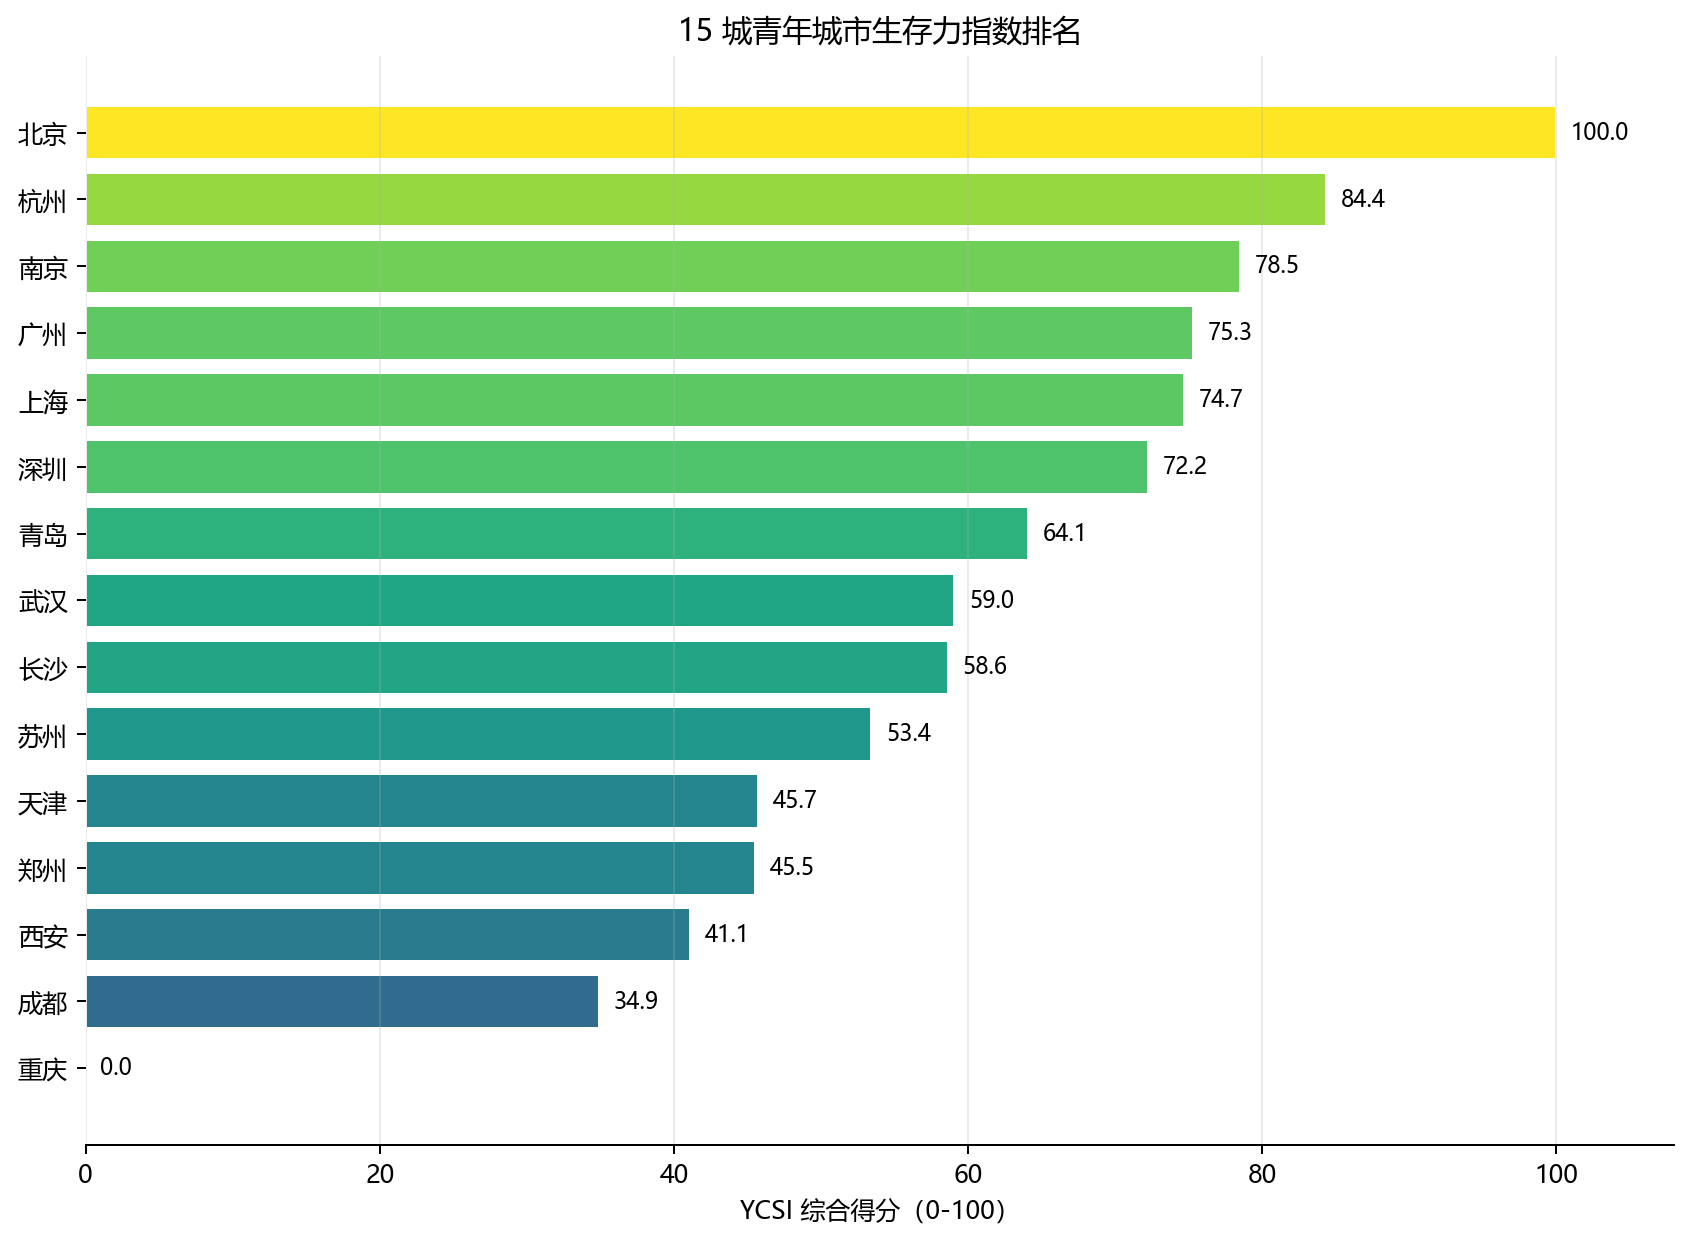

In [23]:
path1 = plot_ycsi_ranking(final_metrics)
print(f"生成: {path1}")
# YCSI排名柱状图

display(Image(path1))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\02_ycsi_city_heat_points.png


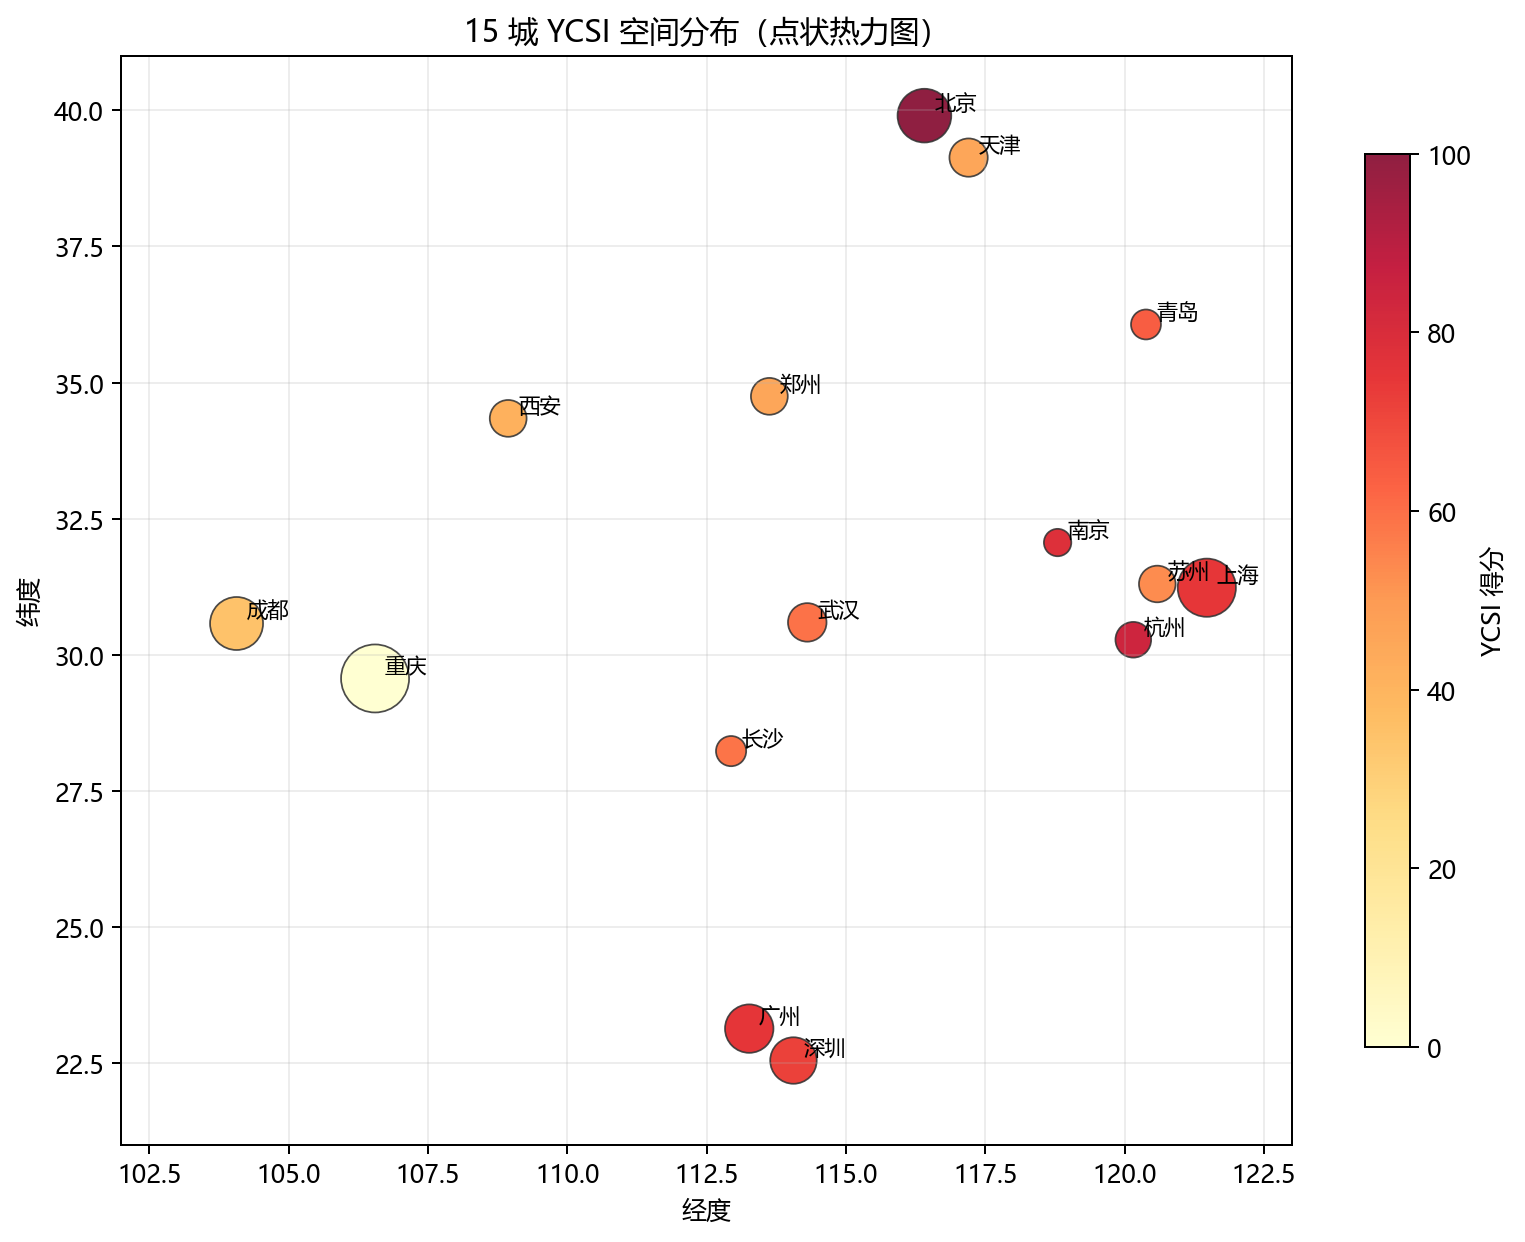

In [24]:
path2 = plot_city_heat_points(final_metrics)
print(f"生成: {path2}")
# 空间分布点状热力图

display(Image(path2))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\03_salary_rent_bubble.png


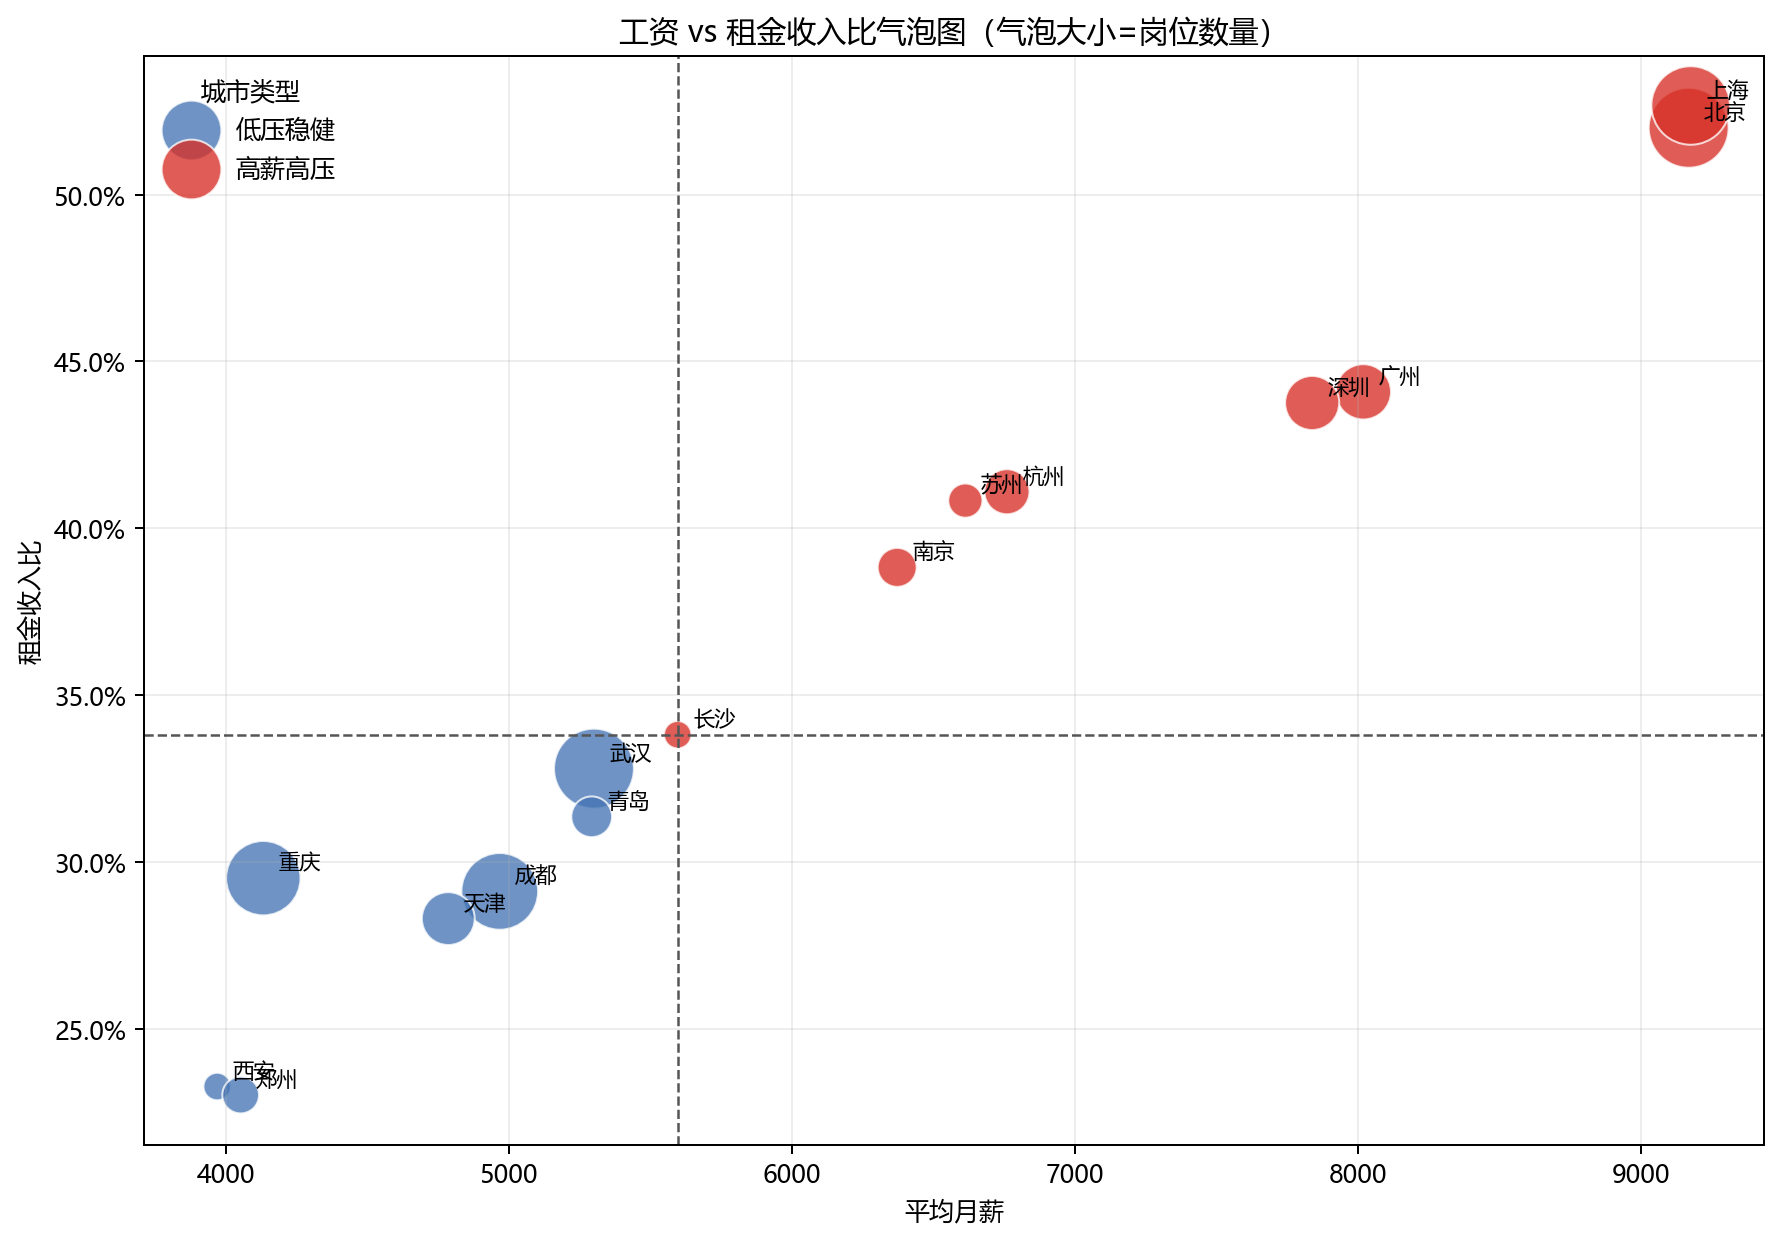

In [25]:
path3 = plot_salary_rent_bubble(final_metrics)
print(f"生成: {path3}")
# 工资 vs 租金收入比气泡图

display(Image(path3))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\04_opportunity_pressure_quadrant.png


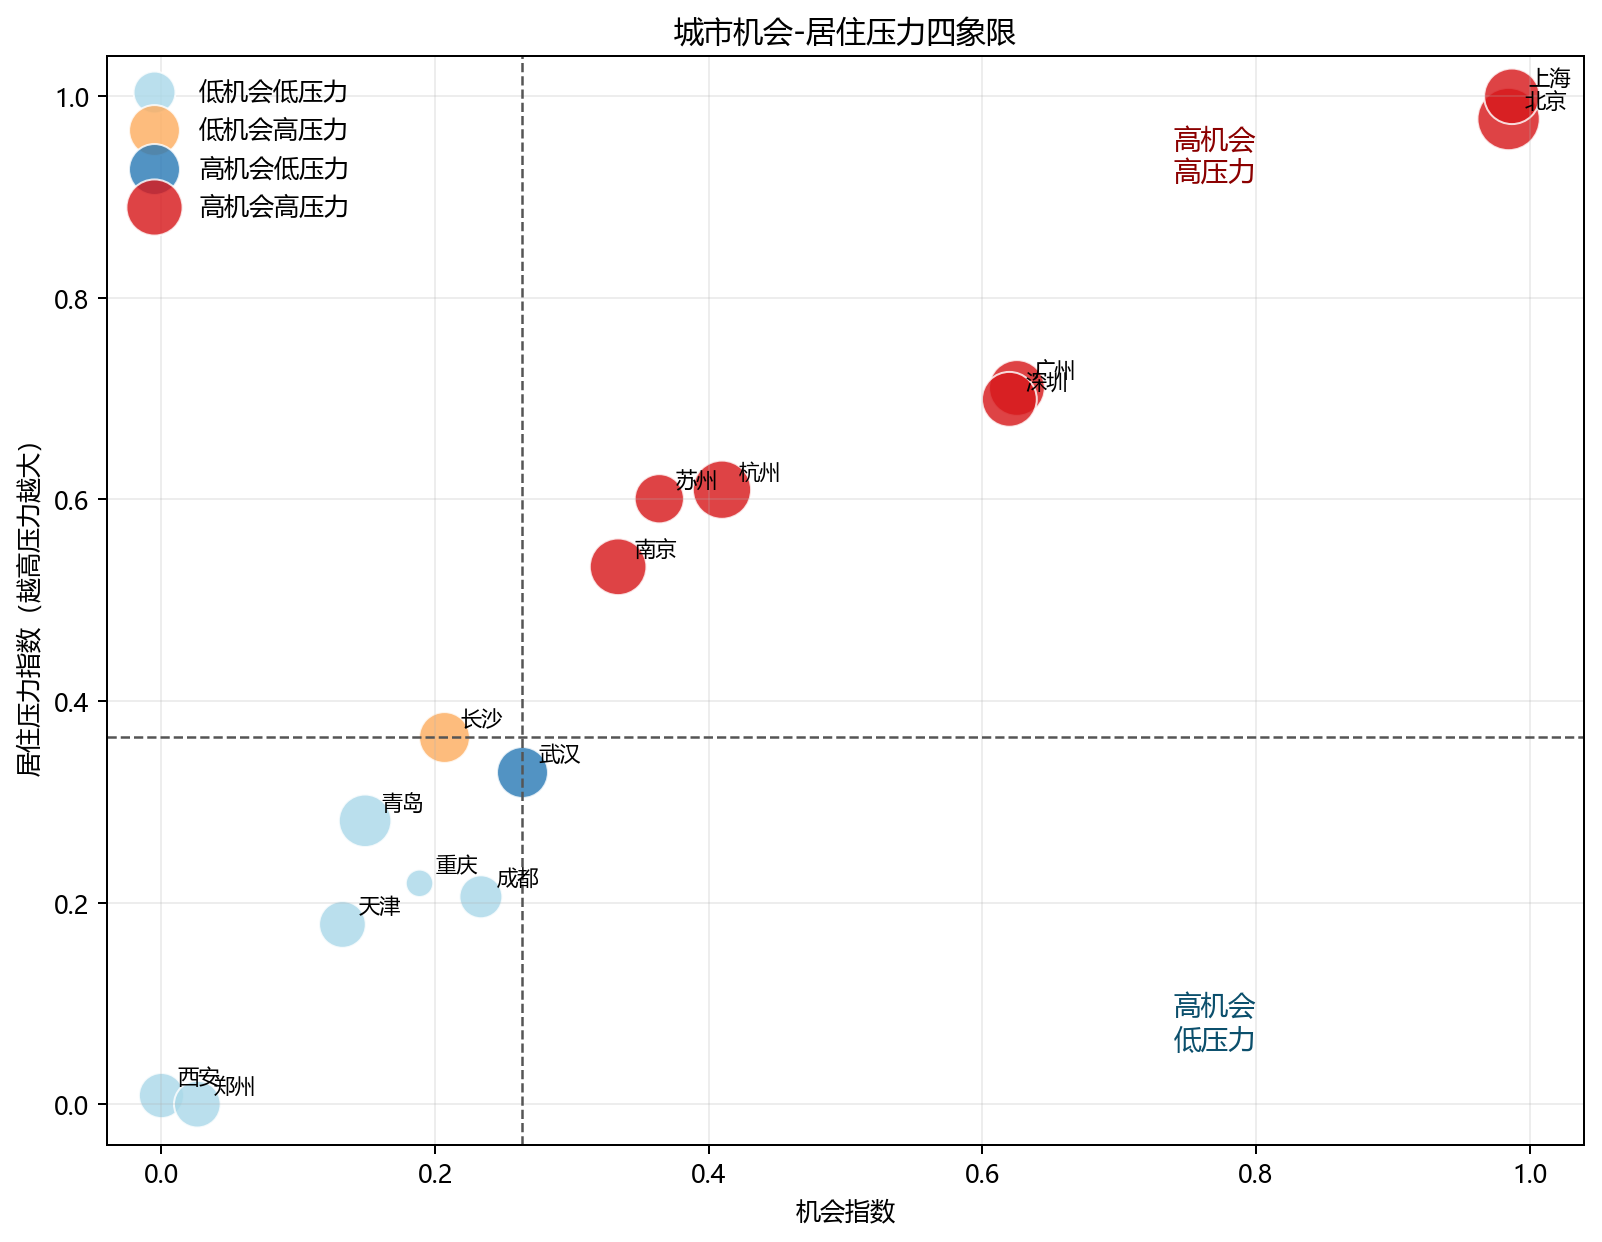

In [26]:
path4 = plot_opportunity_pressure_quadrant(final_metrics)
print(f"生成: {path4}")
# 机会-居住压力四象限图

display(Image(path4))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\05_city_radar.png


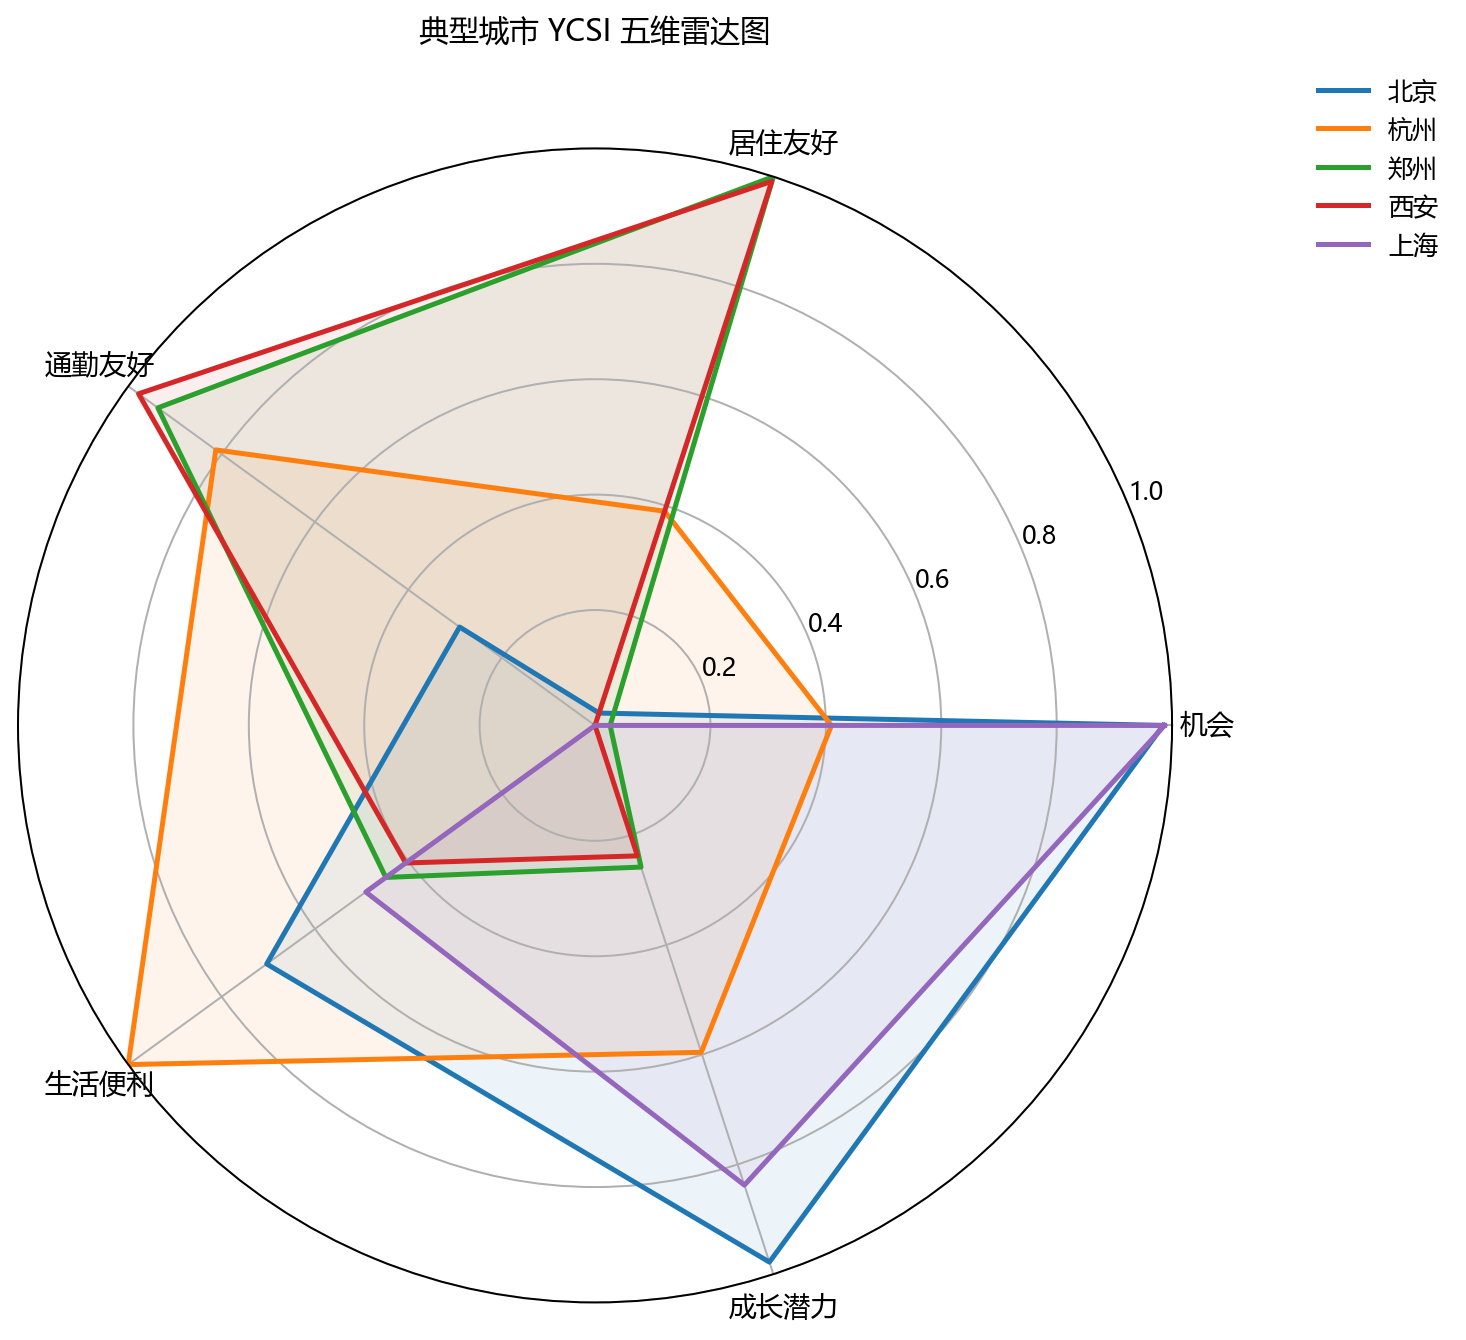

In [27]:
path5 = plot_city_radar(final_metrics)
print(f"生成: {path5}")
# 典型城市雷达图

display(Image(path5))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\06_poi_convenience_stack.png


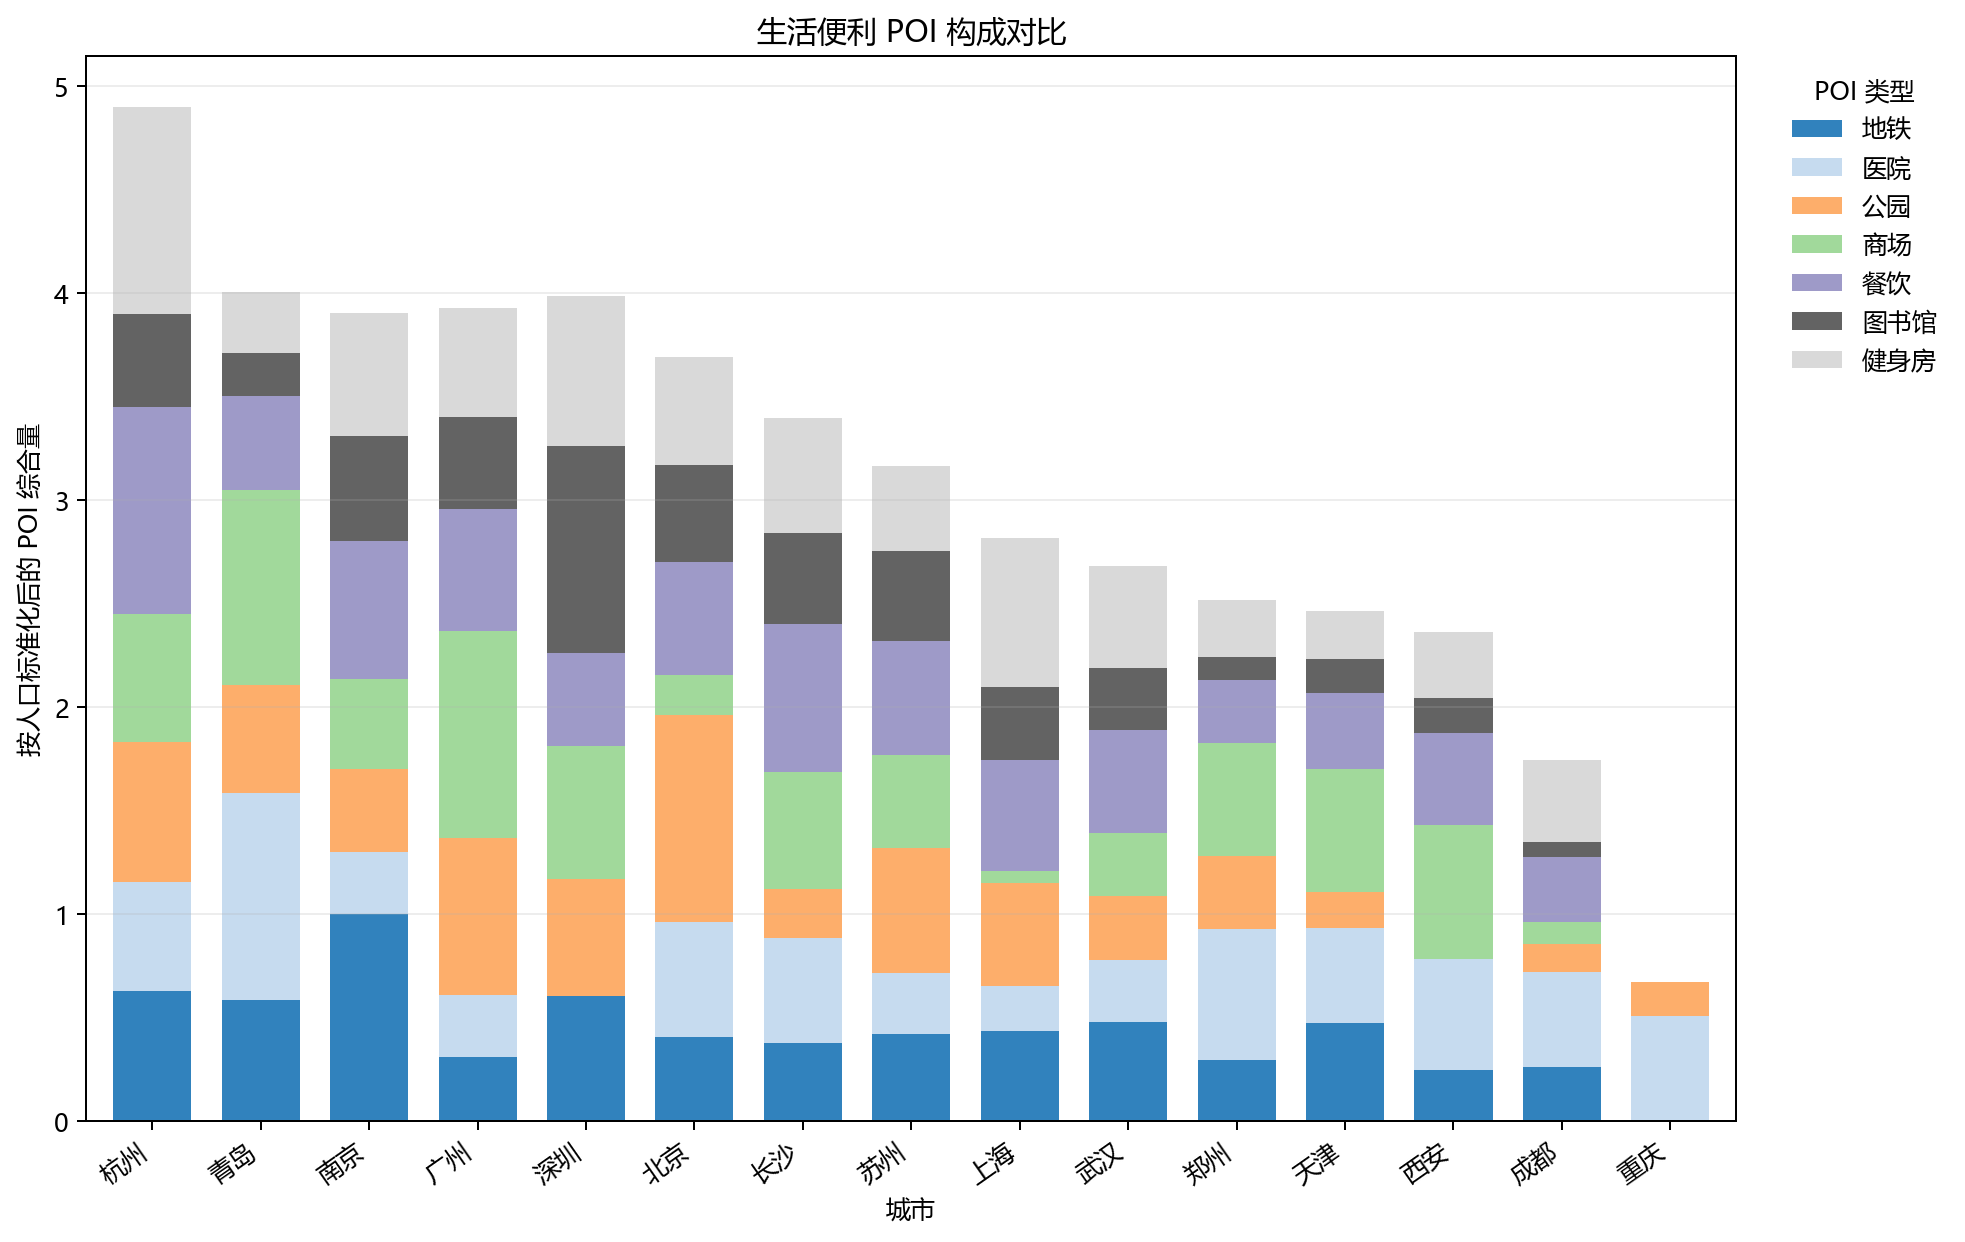

In [28]:
path6 = plot_poi_stack(final_metrics, poi_scaled)
print(f"生成: {path6}")
# 生活便利 POI 堆叠图

display(Image(path6))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\07_metric_correlation_heatmap.png


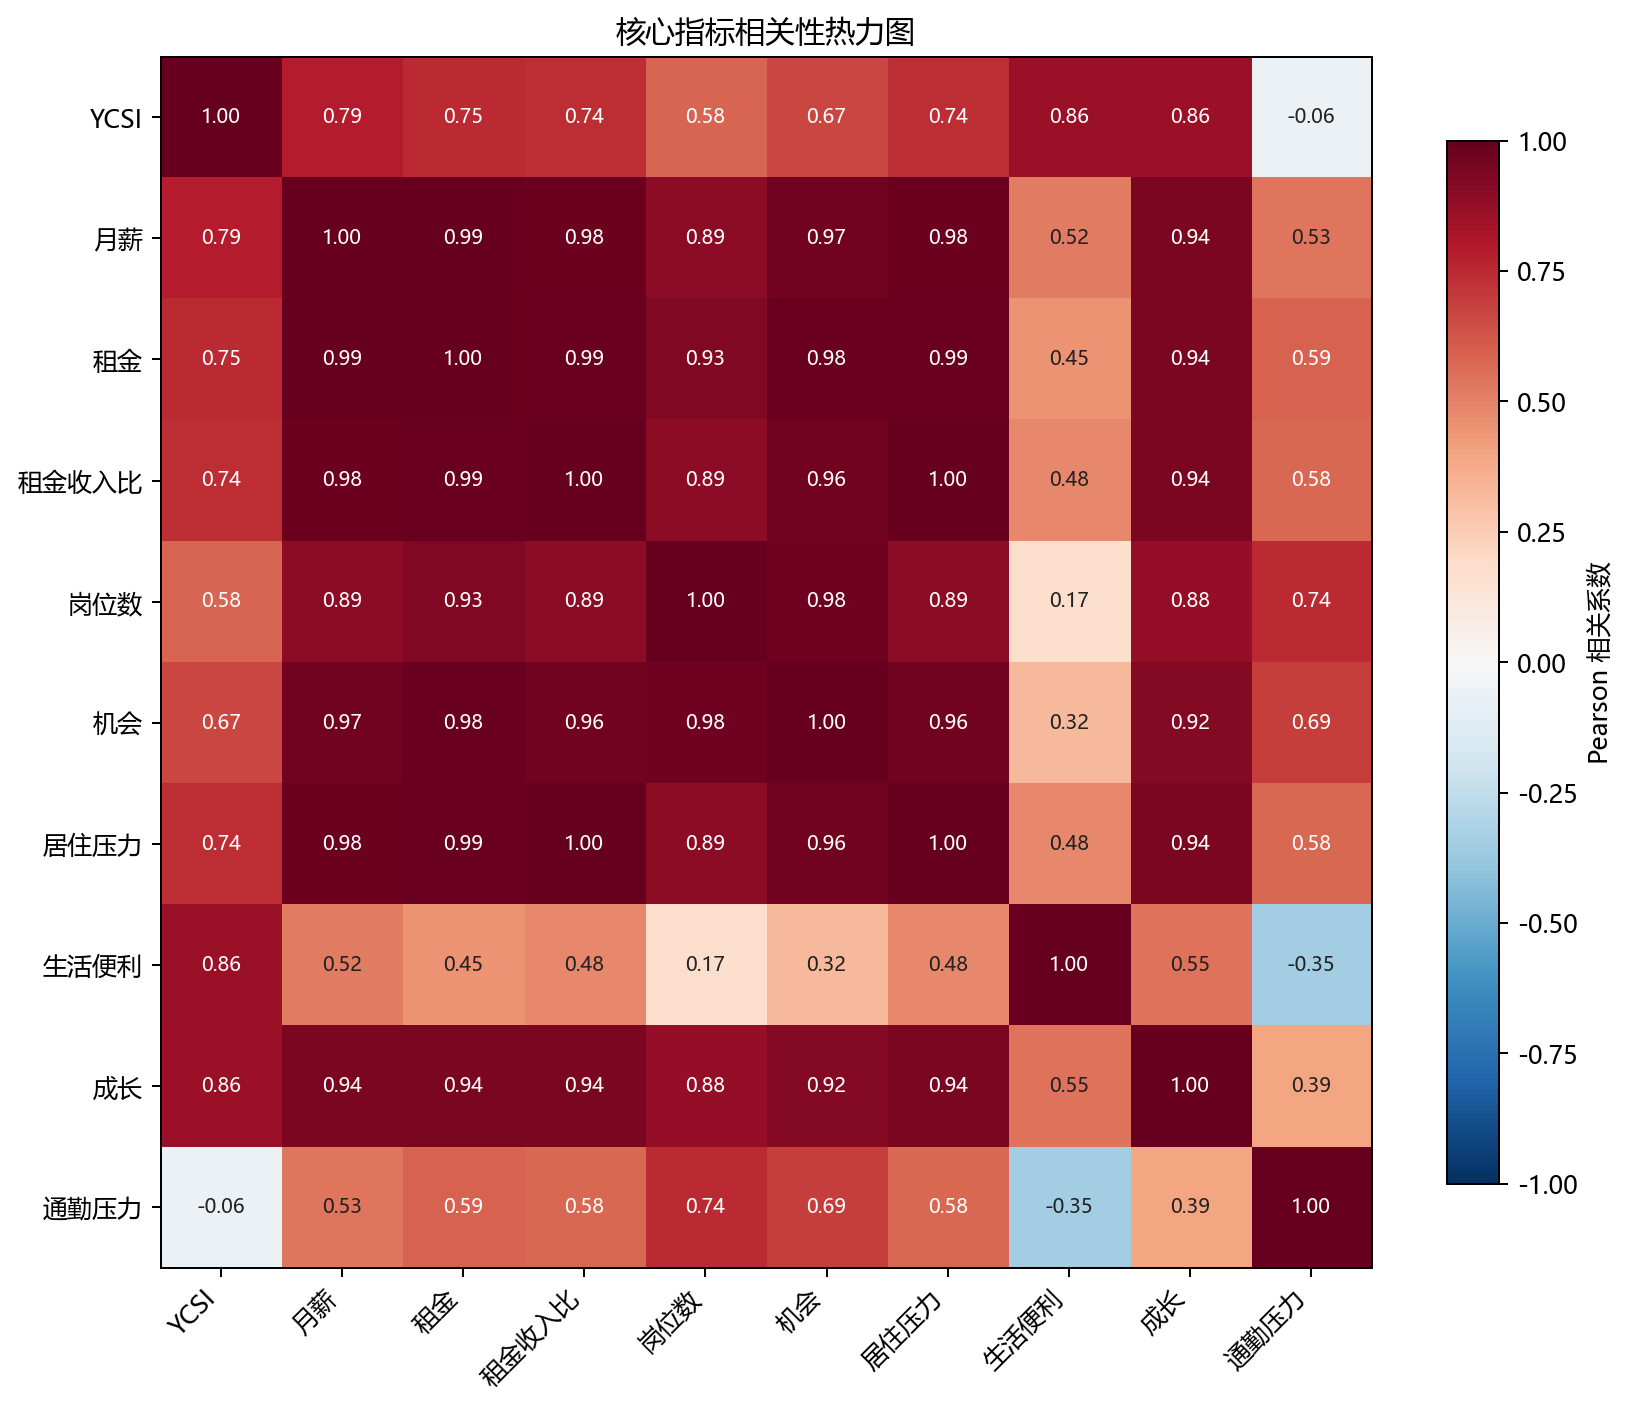

In [29]:
path7 = plot_correlation_heatmap(final_metrics)
print(f"生成: {path7}")
# 指标相关性热力图

display(Image(path7))

生成: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\08_city_clusters.png
聚类汇总表: c:\Users\11411\Desktop\file\work\Shujufenxi&Keshihua\Project\outputs\cluster_summary.csv


,cluster_name,city_list,avg_ycsi,city_count
0,低压稳健型,武汉、西安、长沙、郑州、天津、青岛,52.34,6
1,大城通勤压力型,成都、重庆,17.44,2
2,机会成长型,广州、深圳、杭州、南京、苏州,72.75,5
3,高机会高压力型,北京、上海,87.34,2


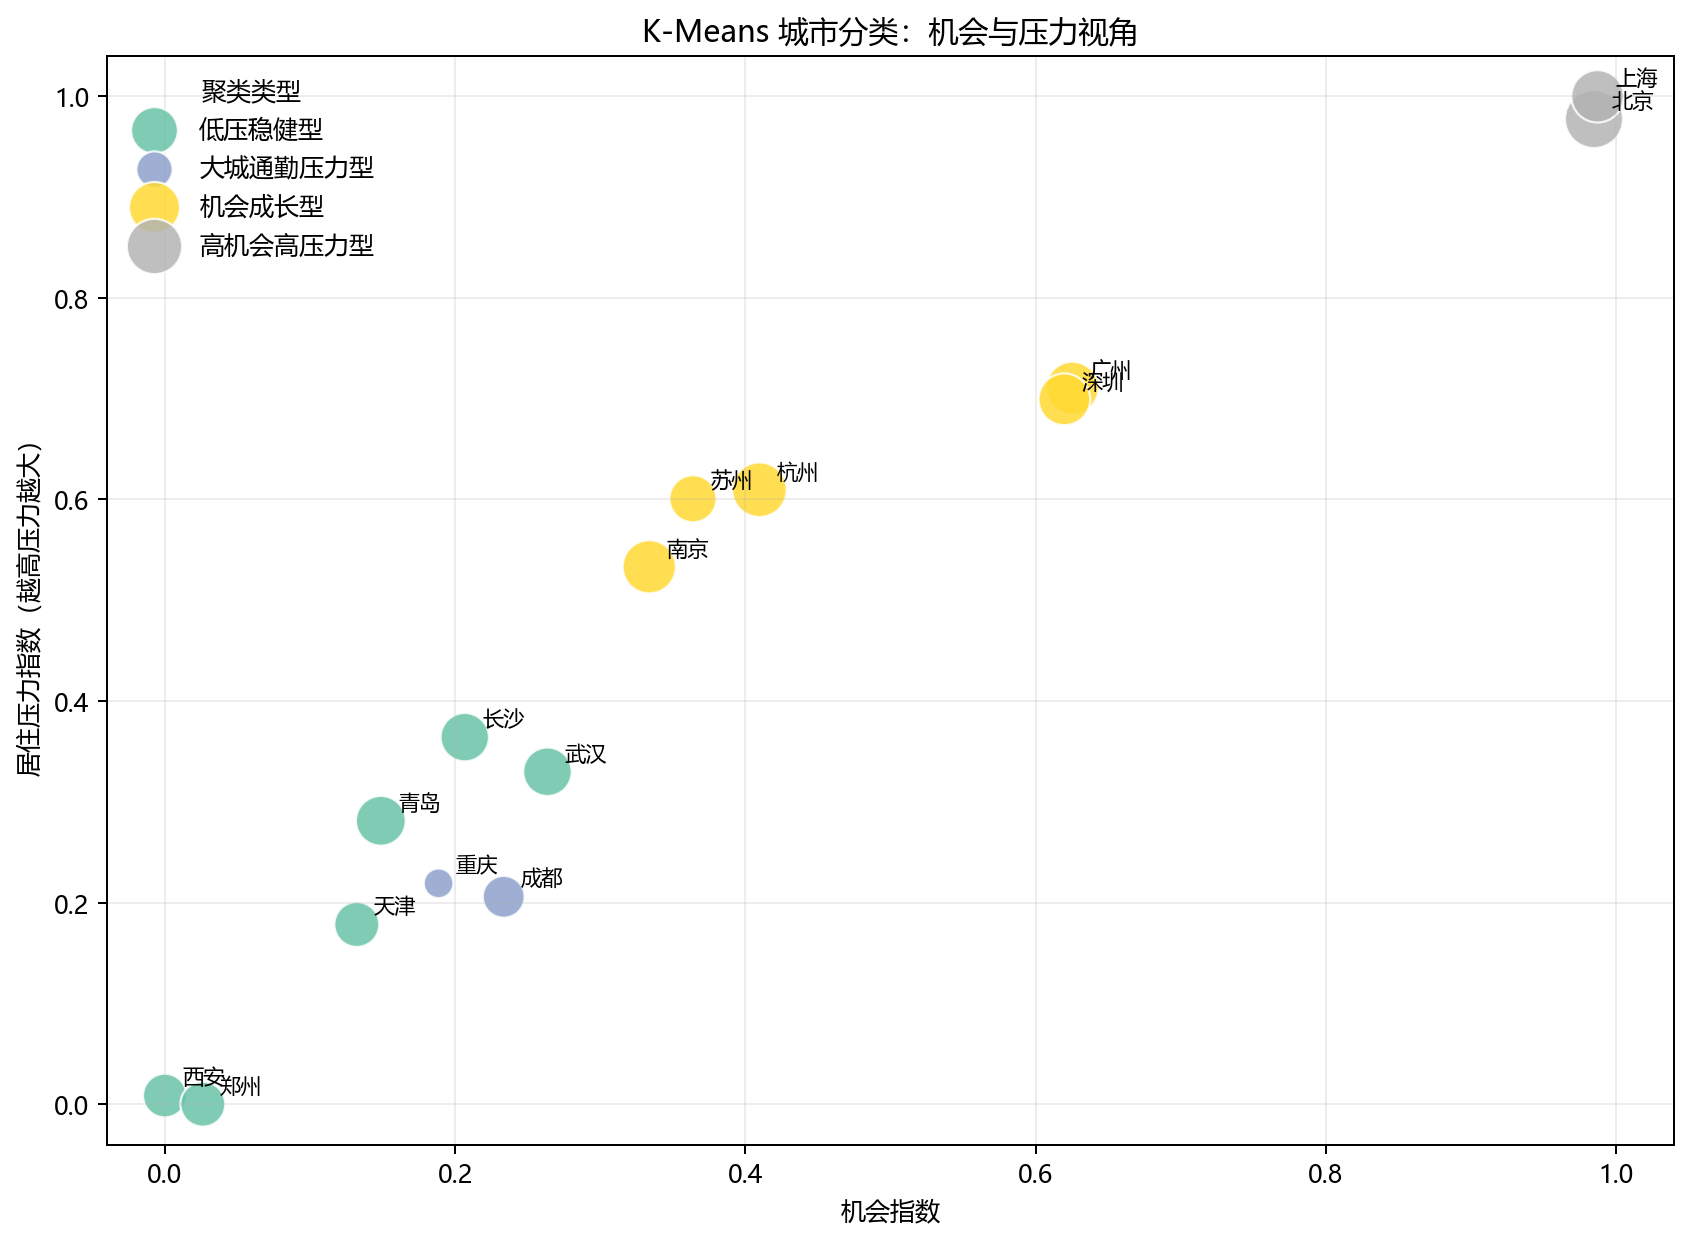

In [30]:
path8, cluster_summary = plot_city_clusters(final_metrics)
cluster_summary_file = export_cluster_summary(cluster_summary)
print(f"生成: {path8}")
print(f"聚类汇总表: {cluster_summary_file}")
display(cluster_summary)  # 在 notebook 中显示表格
# K-Means 城市聚类图（同时输出聚类汇总表）

display(Image(path8))

In [ ]:
print("数据来源说明：")
for note in data_notes:
    print(f"- {note}")

print("\nYCSI Top 5：")
print(final_metrics.sort_values("rank")[["rank", "city", "ycsi"]].head(5).to_string(index=False))

# 打印数据来源说明与 YCSI Top5


数据来源说明：
- 招聘数据：未发现可用 job_data.csv，使用宏观指标生成演示薪资/岗位数。
- 租房数据：未发现可用 rent_data.csv，使用宏观指标生成演示租金。

YCSI Top 5：
 rank city   ycsi
    1   北京 100.00
    2   杭州  84.36
    3   南京  78.46
    4   广州  75.30
    5   上海  74.69
